<a href="https://colab.research.google.com/github/idanidan29/Fake-News-Detection-Model/blob/main/Fake_News_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ── Cell 0: Install & Setup ─────────────────────────────────────────────
!pip install textblob --quiet
!python -m nltk.downloader stopwords wordnet omw-1.4 --quiet

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, RocCurveDisplay
)
from scipy.sparse import hstack, csr_matrix

import keras
from keras import layers

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Setup complete.")


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
Setup complete.


Removed 13,528 duplicate rows. Remaining: 63,143
Stratified sample size: 20002
Cleaned label value counts:
label
0    10000
1    10000
Name: count, dtype: int64


/tmp/ipykernel_2646/4195474196.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 10000), random_state=42))


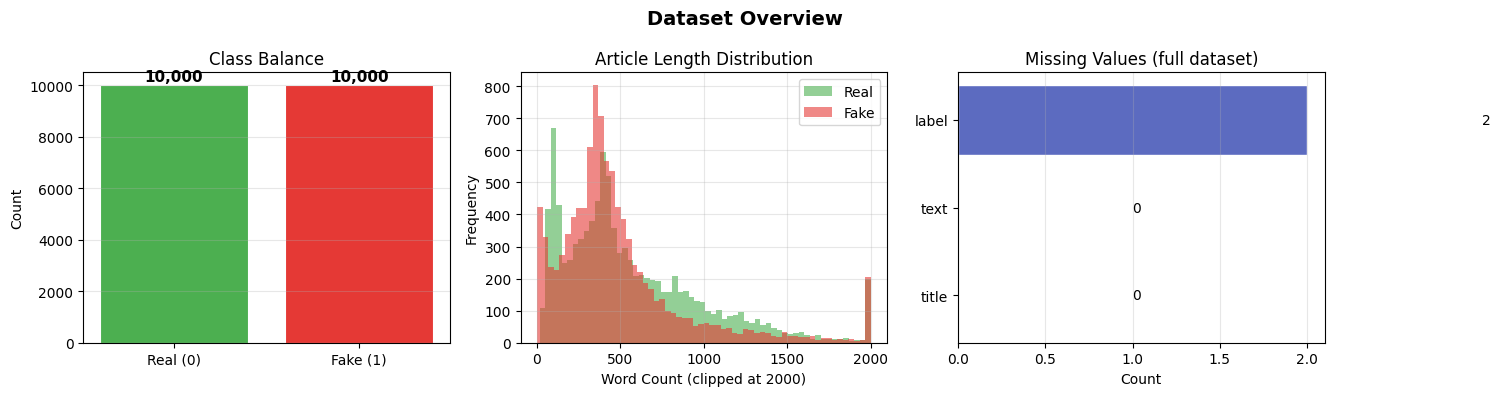

In [16]:
# ── Cell 1: Load & Deduplicate ──────────────────────────────────────────
# WELFake contains article text with unescaped quotes → use Python engine
df = pd.read_csv(
    "/content/sample_data/WELFake_Dataset.csv",
    engine="python",
    on_bad_lines="skip",
)

df.dropna(subset=["title", "text"], inplace=True)
df["full_content"] = df["title"].astype(str) + " " + df["text"].astype(str)

before = len(df)
df.drop_duplicates(subset="full_content", inplace=True)
print(f"Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}")

df_sample = (
    df.groupby("label", group_keys=False)
      .apply(lambda g: g.sample(min(len(g), 10000), random_state=42))
      .reset_index(drop=True)
)
print(f"Stratified sample size: {len(df_sample)}")

# Safety: clean label column (Moved from Cell 3 to resolve ValueError)
df_sample["label"] = pd.to_numeric(df_sample["label"], errors="coerce")
df_sample = df_sample[df_sample["label"].isin([0, 1])].copy()
df_sample["label"] = df_sample["label"].astype(int)
print("Cleaned label value counts:")
print(df_sample["label"].value_counts())

# ── VIZ 1: Dataset Overview ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

# 1a. Class balance
label_counts = df_sample["label"].value_counts().sort_index()
bars = axes[0].bar(["Real (0)", "Fake (1)"], label_counts.values,
                    color=["#4CAF50", "#E53935"], edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

# 1b. Article length distribution (word count)
df_sample["_wc"] = df_sample["full_content"].str.split().str.len()
for label, color, name in [(0, "#4CAF50", "Real"), (1, "#E53935", "Fake")]:
    subset = df_sample[df_sample["label"] == label]["_wc"]
    axes[1].hist(subset.clip(upper=2000), bins=60, alpha=0.6, color=color, label=name)
axes[1].set_title("Article Length Distribution")
axes[1].set_xlabel("Word Count (clipped at 2000)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 1c. Missing values heatmap
missing = df[["title", "text", "label"]].isnull().sum().reset_index()
missing.columns = ["Column", "Missing"]
axes[2].barh(missing["Column"], missing["Missing"], color="#5C6BC0", edgecolor="white")
axes[2].set_title("Missing Values (full dataset)")
axes[2].set_xlabel("Count")
for i, v in enumerate(missing["Missing"]):
    axes[2].text(v + 1, i, str(v), va="center", fontsize=10)
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
df_sample.drop(columns=["_wc"], inplace=True)


##Text Preprocessing

Computing sentiment scores (this may take ~1 min)...
Cleaning text...


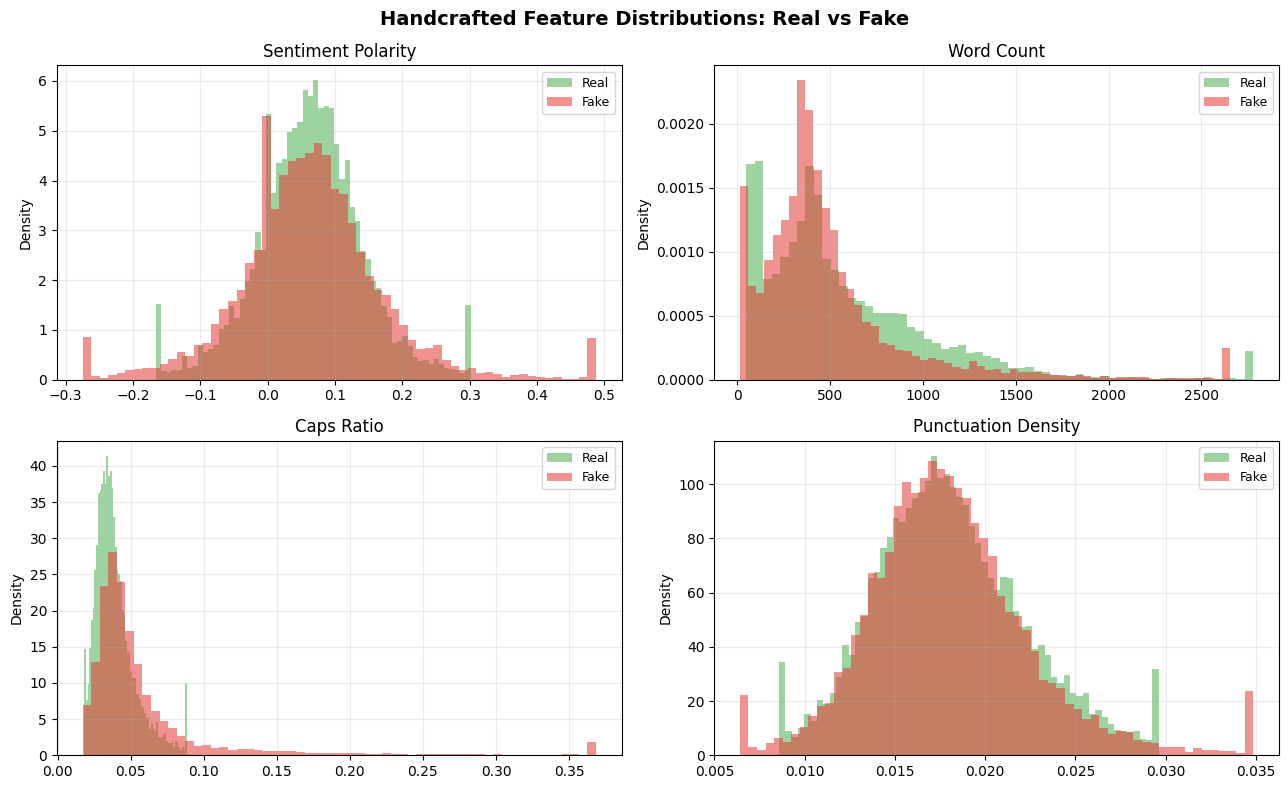

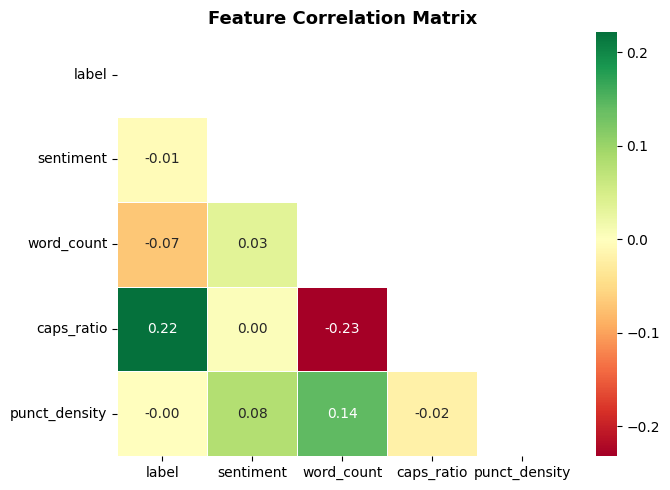


Sample — Before: With military discipline imposed, Trump getting more time for decisions WASHINGTON (Reuters) - Donald Trump’s choice of a general as chief of staff has quickly brought more order to the White House an

Sample — After:  military discipline imposed trump getting time decision washington reuters donald trump choice general chief staff quickly brought order white house giving president time ponder decision try bounce ba


In [17]:
# ── Cell 2: Feature Extraction + Improved clean_text ────────────────────

# IMPROVEMENT 3: Sentiment from RAW text (needs punctuation — before cleaning)
print("Computing sentiment scores (this may take ~1 min)...")
df_sample["sentiment"] = df_sample["full_content"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# IMPROVEMENT 4: Handcrafted stylometric features
df_sample["char_len"]      = df_sample["full_content"].str.len()
df_sample["word_count"]    = df_sample["full_content"].str.split().str.len()
df_sample["caps_ratio"]    = df_sample["full_content"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)
df_sample["punct_density"] = df_sample["full_content"].apply(
    lambda x: sum(1 for c in x if c in "!?.,;:") / max(len(x), 1)
)

# IMPROVEMENT 5: Better clean_text
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "<NUM>", text)
    text = re.sub(r"[^a-zA-Z\s<>]", "", text)
    text = text.lower().strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in STOP_WORDS]
    return " ".join(tokens)

print("Cleaning text...")
df_sample["clean_text"] = df_sample["full_content"].apply(clean_text)

# ── VIZ 2: Handcrafted Feature Distributions by Label ─────────────────────
NUM_FEATS_VIZ = ["sentiment", "word_count", "caps_ratio", "punct_density"]
feat_labels   = ["Sentiment Polarity", "Word Count", "Caps Ratio", "Punctuation Density"]
colors = {0: "#4CAF50", 1: "#E53935"}
label_names = {0: "Real", 1: "Fake"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Handcrafted Feature Distributions: Real vs Fake", fontsize=14, fontweight="bold")

for ax, feat, flabel in zip(axes.flat, NUM_FEATS_VIZ, feat_labels):
    for label in [0, 1]:
        vals = df_sample[df_sample["label"] == label][feat]
        # clip extremes for cleaner plot
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(lo, hi)
        ax.hist(vals, bins=60, alpha=0.55, color=colors[label],
                label=label_names[label], density=True)
    ax.set_title(flabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ── VIZ 3: Feature Correlation Heatmap ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_cols = ["label", "sentiment", "word_count", "caps_ratio", "punct_density"]
corr = df_sample[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={"size": 10})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSample — Before:", df_sample["full_content"].iloc[0][:200])
print("\nSample — After: ", df_sample["clean_text"].iloc[0][:200])


##Train / Val / Test Split

Split: **70% train / 15% val / 15% test**, stratified on label.

Raw label value counts:
label
0    10000
1    10000
Name: count, dtype: int64
Train : 14,008 | Val : 2,992 | Test : 3,000


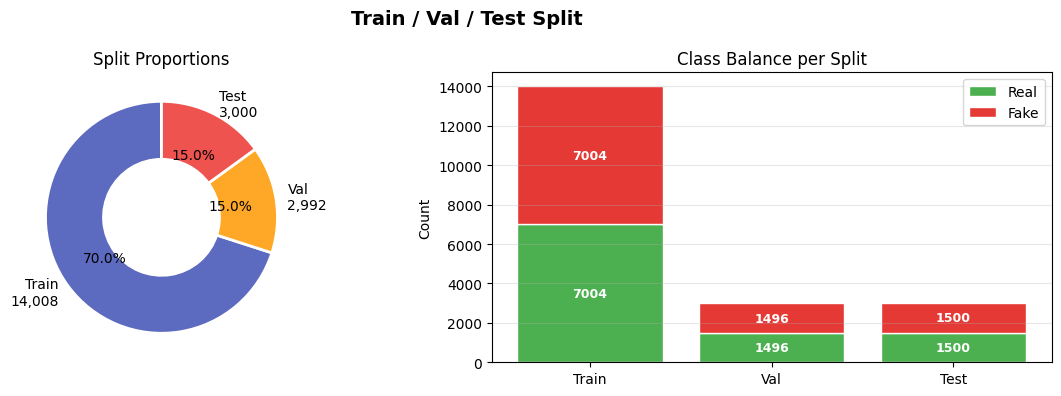

In [18]:
# ── Cell 3: Train / Val / Test Split ────────────────────────────────────

# Safety: clean label column
print("Raw label value counts:")
print(df_sample["label"].value_counts())

df_sample["label"] = pd.to_numeric(df_sample["label"], errors="coerce")
df_sample = df_sample[df_sample["label"].isin([0, 1])].copy()
df_sample["label"] = df_sample["label"].astype(int)

X_text = df_sample["clean_text"]
y      = df_sample["label"]
NUM_FEATS = ["sentiment", "char_len", "word_count", "caps_ratio", "punct_density"]
X_num = df_sample[NUM_FEATS]

X_text_tv, X_text_test, X_num_tv, X_num_test, y_tv, y_test = train_test_split(
    X_text, X_num, y, test_size=0.15, random_state=42, stratify=y
)
X_text_train, X_text_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_text_tv, X_num_tv, y_tv, test_size=0.176, random_state=42, stratify=y_tv
)

print(f"Train : {len(y_train):,} | Val : {len(y_val):,} | Test : {len(y_test):,}")

# ── VIZ 4: Split Summary ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Train / Val / Test Split", fontsize=14, fontweight="bold")

# 4a. Proportions donut
sizes  = [len(y_train), len(y_val), len(y_test)]
labels = [f"Train\n{len(y_train):,}", f"Val\n{len(y_val):,}", f"Test\n{len(y_test):,}"]
wedge_colors = ["#5C6BC0", "#FFA726", "#EF5350"]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=wedge_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
axes[0].set_title("Split Proportions")

# 4b. Class balance per split — stacked bars
splits = {"Train": y_train, "Val": y_val, "Test": y_test}
real_counts = [v.value_counts().get(0, 0) for v in splits.values()]
fake_counts = [v.value_counts().get(1, 0) for v in splits.values()]
x = np.arange(3)
b1 = axes[1].bar(x, real_counts, color="#4CAF50", label="Real", edgecolor="white")
b2 = axes[1].bar(x, fake_counts, bottom=real_counts, color="#E53935", label="Fake", edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(splits.keys())
axes[1].set_ylabel("Count"); axes[1].set_title("Class Balance per Split")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(b1, real_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, val/2, str(val),
                 ha="center", va="center", color="white", fontsize=9, fontweight="bold")
for bar, rc, val in zip(b2, real_counts, fake_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, rc+val/2, str(val),
                 ha="center", va="center", color="white", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 4 · TF-IDF Feature Engineering
Vectorizer is **fit on train only**, then applied (transform-only) to val and test.

Feature matrix shape (train): (14008, 50005)


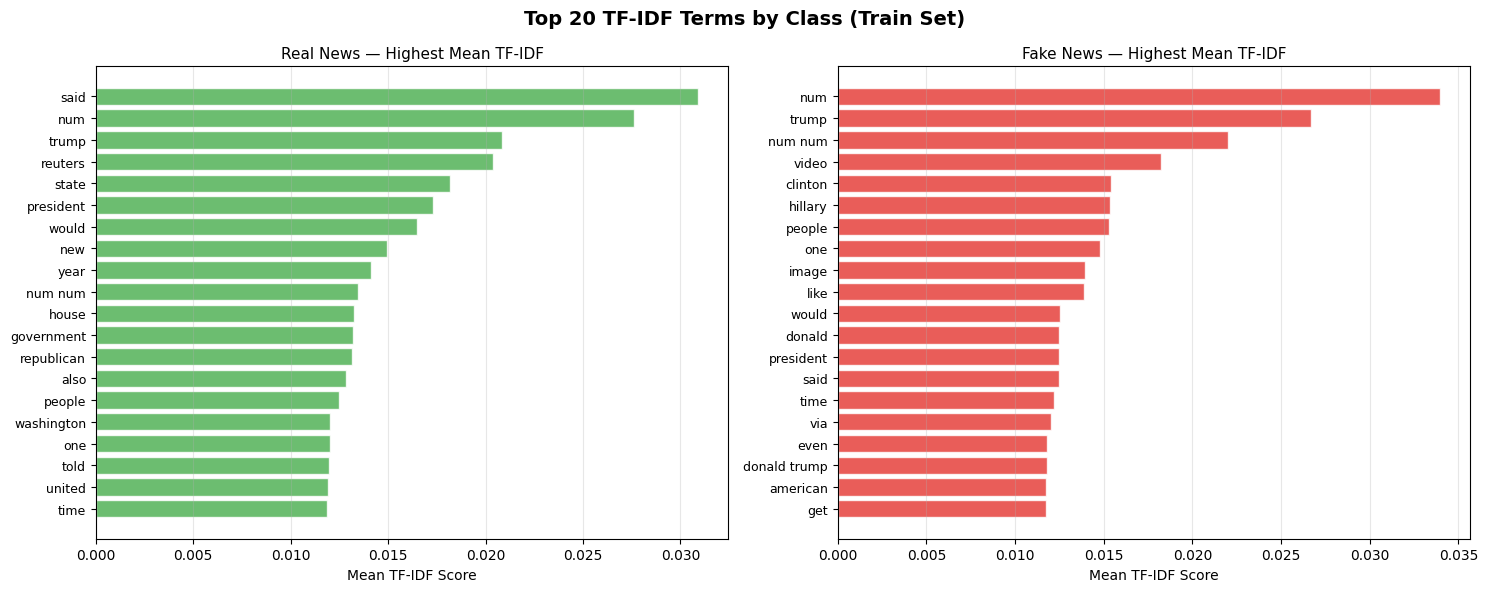

In [19]:
# ── Cell 4: TF-IDF + Numeric Feature Matrix ──────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
)
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_val   = tfidf.transform(X_text_val)
X_tfidf_test  = tfidf.transform(X_text_test)

scaler = StandardScaler()
X_num_train_s = scaler.fit_transform(X_num_train)
X_num_val_s   = scaler.transform(X_num_val)
X_num_test_s  = scaler.transform(X_num_test)

X_train_full = hstack([X_tfidf_train, csr_matrix(X_num_train_s)])
X_val_full   = hstack([X_tfidf_val,   csr_matrix(X_num_val_s)])
X_test_full  = hstack([X_tfidf_test,  csr_matrix(X_num_test_s)])

print(f"Feature matrix shape (train): {X_train_full.shape}")

# ── VIZ 5: Top TF-IDF Terms per Class ────────────────────────────────────
# Compute mean TF-IDF score per term for each class separately
feature_names_arr = np.array(tfidf.get_feature_names_out())
train_idx = X_text_train.index

y_train_arr = y_train.values
real_mask = y_train_arr == 0
fake_mask = y_train_arr == 1

mean_real = np.asarray(X_tfidf_train[real_mask].mean(axis=0)).flatten()
mean_fake = np.asarray(X_tfidf_train[fake_mask].mean(axis=0)).flatten()

top_n = 20
top_real_idx = mean_real.argsort()[-top_n:][::-1]
top_fake_idx = mean_fake.argsort()[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Top 20 TF-IDF Terms by Class (Train Set)", fontsize=14, fontweight="bold")

for ax, indices, means, title, color in [
    (axes[0], top_real_idx, mean_real, "Real News — Highest Mean TF-IDF", "#4CAF50"),
    (axes[1], top_fake_idx, mean_fake, "Fake News — Highest Mean TF-IDF", "#E53935"),
]:
    terms = feature_names_arr[indices]
    scores = means[indices]
    y_pos = np.arange(len(terms))
    bars = ax.barh(y_pos, scores, color=color, alpha=0.82, edgecolor="white")
    ax.set_yticks(y_pos); ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Mean TF-IDF Score")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 5 · Baseline - Logistic Regression

=== Logistic Regression — Validation Set ===
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      1496
        Fake       0.95      0.95      0.95      1496

    accuracy                           0.95      2992
   macro avg       0.95      0.95      0.95      2992
weighted avg       0.95      0.95      0.95      2992

ROC-AUC: 0.9892


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


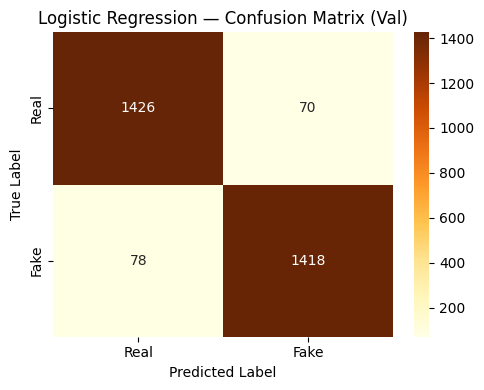

In [20]:
# ── Cell 5: Logistic Regression ─────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, solver="saga", n_jobs=-1)
lr.fit(X_train_full, y_train)

y_val_pred = lr.predict(X_val_full)
y_val_prob = lr.predict_proba(X_val_full)[:, 1]

print("=== Logistic Regression — Validation Set ===")
print(classification_report(y_val, y_val_pred, target_names=["Real", "Fake"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix (Val)")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()


## 6 · Precision-Recall & ROC Curves

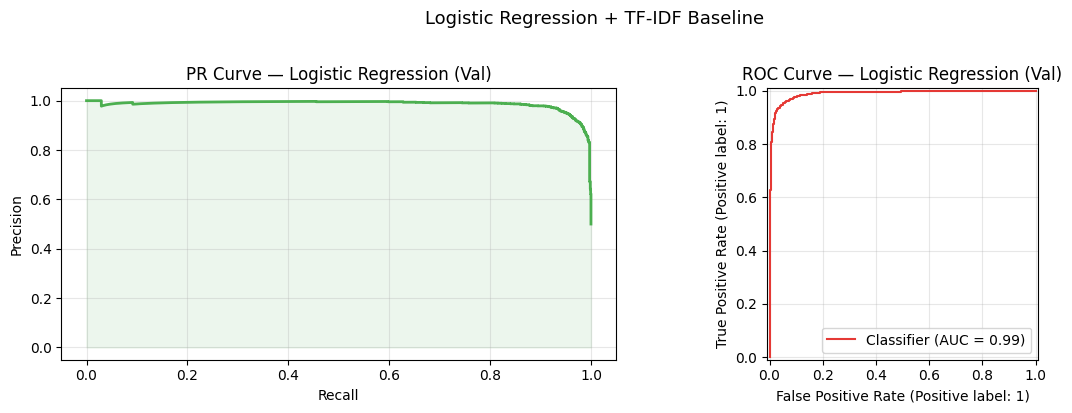

In [21]:
# ── Cell 6: PR & ROC Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, y_val_prob)
axes[0].plot(rec, prec, color="#4CAF50", lw=2)
axes[0].fill_between(rec, prec, alpha=0.1, color="#4CAF50")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("PR Curve — Logistic Regression (Val)")
axes[0].grid(alpha=0.3)

# ROC curve
RocCurveDisplay.from_predictions(y_val, y_val_prob, ax=axes[1], color="#E53935")
axes[1].set_title("ROC Curve — Logistic Regression (Val)")
axes[1].grid(alpha=0.3)

plt.suptitle("Logistic Regression + TF-IDF Baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7 · Most Informative Features
Which words/bigrams does the model find most predictive of fake vs real news?

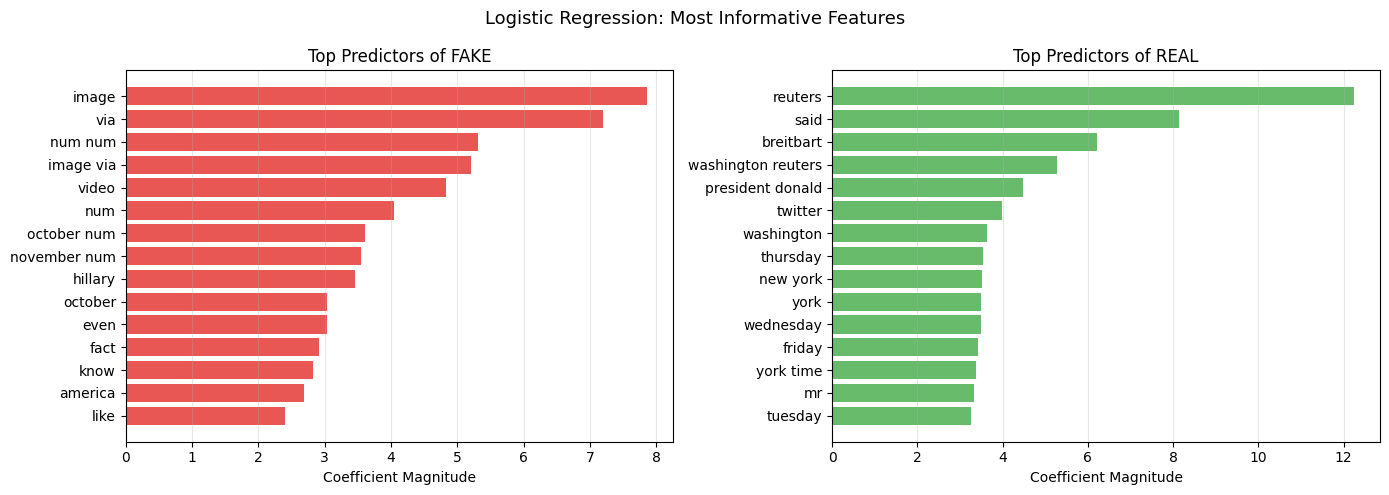

In [22]:
# ── Cell 7: Feature Importance ───────────────────────────────────────────
feature_names = tfidf.get_feature_names_out().tolist() + NUM_FEATS
coefs = lr.coef_[0]

top_n = 15
top_fake_idx = np.argsort(coefs)[-top_n:][::-1]
top_real_idx = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title, color in [
    (axes[0], top_fake_idx, "Top Predictors of FAKE",  "#E53935"),
    (axes[1], top_real_idx, "Top Predictors of REAL",  "#4CAF50"),
]:
    labels = [feature_names[i] for i in indices]
    values = [abs(coefs[i]) for i in indices]
    ax.barh(labels[::-1], values[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Coefficient Magnitude")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Logistic Regression: Most Informative Features", fontsize=13)
plt.tight_layout()
plt.show()


## 8 · Final Evaluation on Test Set


=== Logistic Regression — FINAL TEST SET ===
              precision    recall  f1-score   support

        Real       0.94      0.96      0.95      1500
        Fake       0.96      0.94      0.95      1500

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000

ROC-AUC: 0.9884


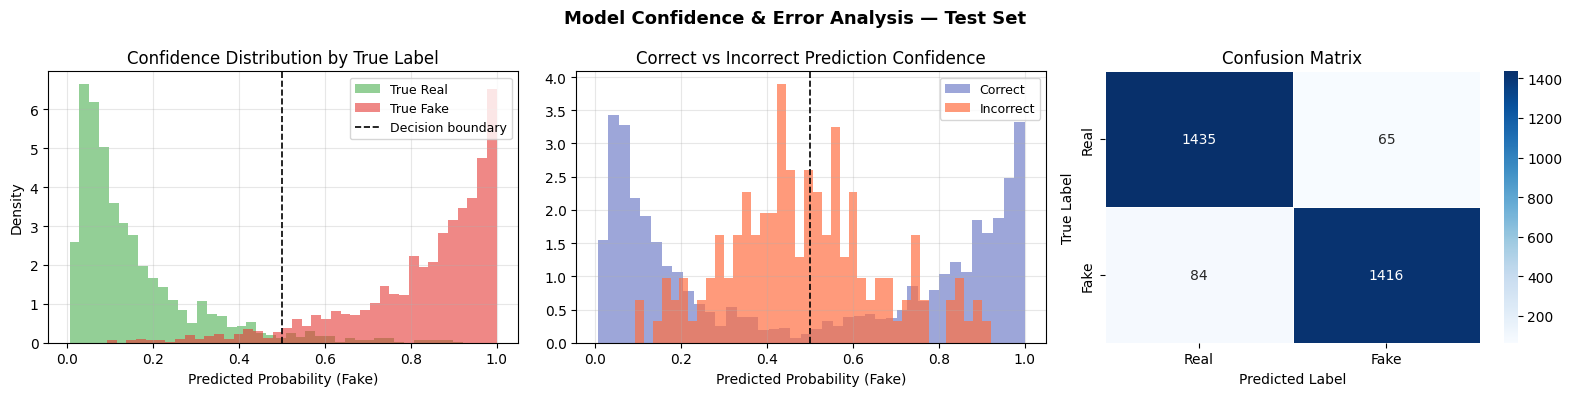


Misclassified: 149 / 3000 (5.0%)

--- Most confident wrong predictions (hardest errors) ---
  True: Real | Predicted: Fake | Confidence: 92.10%
  RABBI SHMULEY: Will AIPAC Honor Trump’s Defense of Israel at the UN? - Breitbart President Donald Trump’s recent defense of Israel at the United Nations is almost unprecedented, and warrants the appreciation and gratitud...

  True: Fake | Predicted: Real | Confidence: 90.68%
  As Daylight Saving Starts, Some Ask: Why Fall Back at All? - The New York Times DAMARISCOTTA, Me.  —   Several years ago, the owner of a sandwich shop on the main drag here grew so tired of turning the clocks back in the...

  True: Fake | Predicted: Real | Confidence: 89.64%
  Iran’s carpet exports to US at $50mn Iran’s carpet exports to US at $50mn Thu Oct 27, 2016 5:55AM Economy Iran says it exported about $50 million of hand-woven carpets to the United States since the removal of sanctions ...



In [23]:
# ── Cell 8: Test Set Evaluation ──────────────────────────────────────────
y_test_pred = lr.predict(X_test_full)
y_test_prob = lr.predict_proba(X_test_full)[:, 1]

print("=== Logistic Regression — FINAL TEST SET ===")
print(classification_report(y_test, y_test_pred, target_names=["Real", "Fake"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")

# ── VIZ 8: Prediction Confidence Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Model Confidence & Error Analysis — Test Set", fontsize=13, fontweight="bold")

# 8a. Confidence histogram by true label
for true_label, color, name in [(0, "#4CAF50", "Real"), (1, "#E53935", "Fake")]:
    mask = y_test.values == true_label
    axes[0].hist(y_test_prob[mask], bins=40, alpha=0.6, color=color, label=f"True {name}", density=True)
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision boundary")
axes[0].set_xlabel("Predicted Probability (Fake)")
axes[0].set_ylabel("Density")
axes[0].set_title("Confidence Distribution by True Label")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 8b. Confidence of CORRECT vs WRONG predictions
correct_mask = y_test.values == y_test_pred
axes[1].hist(y_test_prob[correct_mask],  bins=40, alpha=0.6, color="#5C6BC0", label="Correct",   density=True)
axes[1].hist(y_test_prob[~correct_mask], bins=40, alpha=0.7, color="#FF7043", label="Incorrect", density=True)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Predicted Probability (Fake)")
axes[1].set_title("Correct vs Incorrect Prediction Confidence")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# 8c. Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            ax=axes[2], linewidths=0.5)
axes[2].set_title("Confusion Matrix")
axes[2].set_ylabel("True Label")
axes[2].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# Misclassified examples
df_test_slice = df_sample.loc[X_text_test.index].copy()
df_test_slice["predicted"] = y_test_pred
df_test_slice["confidence"] = np.where(
    y_test_pred == 1, y_test_prob, 1 - y_test_prob
)
mistakes = df_test_slice[df_test_slice["label"] != df_test_slice["predicted"]]
print(f"\nMisclassified: {len(mistakes)} / {len(y_test)} ({100*len(mistakes)/len(y_test):.1f}%)")
print("\n--- Most confident wrong predictions (hardest errors) ---")
for _, row in mistakes.nlargest(3, "confidence").iterrows():
    true_label = "Real" if row["label"] == 0 else "Fake"
    pred_label = "Real" if row["predicted"] == 0 else "Fake"
    print(f"  True: {true_label} | Predicted: {pred_label} | Confidence: {row['confidence']:.2%}")
    print(f"  {row['full_content'][:220]}...")
    print()
